In [1]:
import torch
import torch.nn as nn
import torch.optim as optim 
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from transformers import BertTokenizerFast
from datasets import load_dataset
import numpy as np
from torchmetrics import Accuracy
from tqdm import tqdm

/home/ariyana-soft/Desktop/Demis/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#1. Dataset
from datasets import load_dataset
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")
print("=== Dataset Structure ===")
print(dataset)
print("= * 30")
splits = list(dataset.keys())
print(f"Available Splits: {splits}")
print(f"Number of Training examples: {len(dataset['train'])}")
print(f"Number of Test examples: {len(dataset['test'])}")
print(f"Number of Validation examples: {len(dataset['validation'])}")
features = dataset['train'].features
print("\nDataset Features/Columns:", list(features.keys()))
print(f"Text Column:  'text'  -> Type: {features['text']}")
print(f"Label Column: 'label' -> Type: {features['label']}")

=== Dataset Structure ===
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
= * 30
Available Splits: ['train', 'test', 'validation']
Number of Training examples: 45615
Number of Test examples: 12284
Number of Validation examples: 2000

Dataset Features/Columns: ['text', 'label']
Text Column:  'text'  -> Type: Value('string')
Label Column: 'label' -> Type: ClassLabel(names=['negative', 'neutral', 'positive'])


In [3]:
#1.2 Inspect the Dataset
sentiment_categories = {
    0:"Negative",
    1:"Neutral",
    2:"Positive"
}
print("5 Examples from the Train Split")
for i in range(5):
    example = dataset['train'][i]
    original_text = example['text']
    numerical_label = example['label']
    sentiment_category = sentiment_categories[numerical_label]
print(f"Example {i + 1}:")
print(f"Original Text: {original_text}")
print(f"Numerical Label: {numerical_label}")
print(f"Sentiment Category: {sentiment_category}")

5 Examples from the Train Split
Example 5:
Original Text: @user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"
Numerical Label: 2
Sentiment Category: Positive


In [4]:
from transformers import BertTokenizerFast
import torch
tokenizer_name = "bert-base-uncased"
tokenizer = BertTokenizerFast.from_pretrained(tokenizer_name)
max_length = 64
print(f"Tokenizer Name: {tokenizer_name}")
print(f"Vocabulary Size: {tokenizer.vocab_size}")
print(f"PAD Token ID: {tokenizer.pad_token_id} ('{tokenizer.pad_token}')")
print(f"UNK Token ID: {tokenizer.unk_token_id} ('{tokenizer.unk_token}')")
print(f"Chosen Max Length: {max_length}")
def preprocess_function(examples):
    return tokenizer(
        examples["text"],
        truncation = True,
        max_length = max_length,
        padding = "max_length"
        )
tokenized_datasets = dataset.map(preprocess_function, batched=True)
tokenized_datasets.set_format(type='torch', columns=['label', 'input_ids', 'attention_mask'])
print("\n Preprocessing Completed Successfully!\n")

Tokenizer Name: bert-base-uncased
Vocabulary Size: 30522
PAD Token ID: 0 ('[PAD]')
UNK Token ID: 100 ('[UNK]')
Chosen Max Length: 64

 Preprocessing Completed Successfully!



In [6]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_loader = DataLoader(tokenized_datasets['train'], batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(tokenized_datasets['validation'], batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(tokenized_datasets['test'], batch_size=BATCH_SIZE, shuffle=False)
print(f"Number of Train batches: {len(train_loader)}")
print(f"Number of Validation batches: {len(valid_loader)}")
print(f"Number of Test batches: {len(test_loader)}")
batch = next(iter(train_loader))
print("Keys in batch:", batch.keys())
print("\nBatch Shapes:")
print(f"label shape: {batch['label'].shape}")
print(f"input_ids shape: {batch['input_ids'].shape}")
print(f"ateention_mask shape: {batch['attention_mask'].shape}")

Number of Train batches: 1426
Number of Validation batches: 63
Number of Test batches: 384
Keys in batch: dict_keys(['label', 'input_ids', 'attention_mask'])

Batch Shapes:
label shape: torch.Size([32])
input_ids shape: torch.Size([32, 64])
ateention_mask shape: torch.Size([32, 64])


In [7]:
#2. Neural Network Model 
import torch
import torch.nn as nn
class RNNModel(nn.Module):
    def __init__(self, RNN, vocab_size, input_size, hidden_size, num_layers, bidirectional, num_cls):
        super(RNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, input_size)
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=bidirectional,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size * (2 if bidirectional else 1), num_cls)
    def forward(self, x):
        x = self.embedding(x)
        outputs, hidden = self.rnn(x)
        x = outputs.mean(dim=1)
        x = self.fc(x)
        return x

In [9]:
VOCAB_SIZE = tokenizer.vocab_size 
INPUT_SIZE = 128  
HIDDEN_SIZE = 256
NUM_LAYERS = 1
BIDIRECTIONAL = True 
NUM_CLS = 3

model = RNNModel(
    RNN=nn.RNN,
    vocab_size=VOCAB_SIZE,
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    num_cls=NUM_CLS
)
print(model)

RNNModel(
  (embedding): Embedding(30522, 128)
  (rnn): RNN(128, 256, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=512, out_features=3, bias=True)
)


In [11]:
VOCAB_SIZE = 30522
EMBEDDING_DIM = 128    
HIDDEN_DIM = 256        
NUM_LAYERS = 1           
MAX_SEQ_LENGTH = 64      
OUTPUT_CLASSES = 3          
print(f"Model Hyperparameters: ")
print(f"Vocabulary Size: {VOCAB_SIZE}")
print(f"Embedding Dimension: {EMBEDDING_DIM}")
print(f"RNN Hidden Dimension: {HIDDEN_DIM}")
print(f"Number of RNN Layers: {NUM_LAYERS}")
print(f"Maximum Sequence Length: {MAX_SEQ_LENGTH}")
print(f"Number of Output Classes: {OUTPUT_CLASSES}")

Model Hyperparameters: 
Vocabulary Size: 30522
Embedding Dimension: 128
RNN Hidden Dimension: 256
Number of RNN Layers: 1
Maximum Sequence Length: 64
Number of Output Classes: 3


## 2.2 Model Hyperparameters

The model configuration is set as follows:

*   Vocabulary Size: 30522
*   Embedding Dimension: 128
*   RNN Hidden Dimension: 256
*   Number of RNN Layers: 1
*   Maximum Sequence Length: 64
*   Number of Output Classes: 3

### Hyperparameter Justification:

*   Embedding Dimension (128): This value is chosen as a balanced trade-off between the expressive capacity required to capture semantic nuances in tweets and computational efficiency. A dimension of 128 is sufficient for representing word tokens in this specific sentiment analysis task without introducing redundant parameters that could lead to overfitting.

*   RNN Hidden Dimension (256): I selected 256 to ensure the model has sufficient memory capacity to capture sequential dependencies and aggregate long-range context across the sequence. This size allows the RNN layer to effectively map the sequence representation into a feature space suitable for the subsequent linear classification layer.

In [13]:
#2.3 Loss Function and Optimizer
import torch.nn as nn
import torch.optim as optim
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01 , momentum=0.9)


## 2.3 Loss Function and Optimizer

- Loss Function: CrossEntropyLoss was selected as it is the standard and most appropriate loss function for multi-class classification problems (3 classes: Negative, Neutral, Positive). It internally applies Softmax and computes Cross-Entropy between predicted logits and target labels.
- Optimizer: Stochastic Gradient Descent (`SGD`) is utilized as required by the assignment guidelines to update model parameters during training.
- Learning Rate: A starting learning rate of 0.01 was specified to ensure stable convergence during training.

In [ ]:
# Device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")
model = model.to(device)

Using Device: cpu


In [ ]:
#Model Training 
class AverageMeter(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [18]:
from tqdm import tqdm
from torchmetrics.classification import Accuracy

# تابع آموزش
def train_one_epoch(model, train_loader, loss_fn, optimizer, epoch=None):
    model.train()
    loss_train = AverageMeter()
    acc_train = Accuracy(task='multiclass', num_classes=3).to(device)
    
    with tqdm(train_loader, unit='batch') as tepoch:
        for batch in tepoch:
            if epoch is not None:
                tepoch.set_description(f"Epoch {epoch}")
            
            inputs = batch['input_ids'].to(device)
            targets = batch['label'].to(device)
            
            optimizer.zero_grad()  
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            loss_train.update(loss.item(), inputs.size(0))
            acc_train.update(outputs, targets)
            tepoch.set_postfix(loss=loss_train.avg, accuracy=100.0 * acc_train.compute().item())
            
    return model, loss_train.avg, acc_train.compute().item()

In [ ]:
# (Validation)
def validation(model, valid_loader, loss_fn):
    model.eval()
    loss_valid = AverageMeter()
    acc_valid = Accuracy(task='multiclass', num_classes=3).to(device)
    
    with torch.no_grad():
        for batch in valid_loader:
            inputs = batch['input_ids'].to(device)
            targets = batch['label'].to(device)
            
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            
            loss_valid.update(loss.item(), inputs.size(0))
            acc_valid.update(outputs, targets)
            
    return loss_valid.avg, acc_valid.compute().item()

In [21]:
# Hyperparameter Tuning
num_epochs = 5  

for lr in [0.1, 0.01, 0.001, 0.0001]:
    print(f"\n--- Testing LR = {lr} ---")
    model = RNNModel(
        nn.RNN,
        vocab_size=VOCAB_SIZE,
        input_size=128,
        hidden_size=256,
        num_layers=1,
        bidirectional=True,
        num_cls=NUM_CLS
    ).to(device)
    
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=1e-4, momentum=0.9)
    
    for epoch in range(num_epochs):
        model, train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, epoch=epoch)
        val_loss, val_acc = validation(model, valid_loader, loss_fn)
        print(f"Epoch {epoch+1}/{num_epochs} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")


--- Testing LR = 0.1 ---


Epoch 0: 100%|██████████| 1426/1426 [02:10<00:00, 10.89batch/s, accuracy=48.3, loss=1.06]


Epoch 1/5 | Val Loss: 0.9915 | Val Acc: 50.60%


Epoch 1: 100%|██████████| 1426/1426 [02:10<00:00, 10.90batch/s, accuracy=54.2, loss=0.949]


Epoch 2/5 | Val Loss: 0.9395 | Val Acc: 55.70%


...

Epoch 3/5 | Val Loss: 1.0133 | Val Acc: 44.60%


Epoch 3: 100%|██████████| 1426/1426 [02:18<00:00, 10.32batch/s, accuracy=46.5, loss=1.01]


Epoch 4/5 | Val Loss: 1.0123 | Val Acc: 45.25%


Epoch 4: 100%|██████████| 1426/1426 [02:16<00:00, 10.46batch/s, accuracy=46.8, loss=1.01]


Epoch 5/5 | Val Loss: 1.0113 | Val Acc: 45.70%


In [22]:
model = RNNModel(
    nn.RNN,
    vocab_size=VOCAB_SIZE,
    input_size=128,
    hidden_size=256,
    num_layers=1,
    bidirectional=True,
    num_cls=NUM_CLS
).to(device)
lr = 0.1
wd = 1e-4
optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=wd, momentum=0.9)

In [23]:
loss_train_hist = []
loss_valid_hist = []
acc_train_hist =   []
acc_valid_hist =[]
best_loss_valid = torch.inf
epoch_counter = 0
num_epochs = 15
for epoch in range(num_epochs):
  #Traim
  model, loss_train, acc_train = train_one_epoch(model, train_loader, loss_fn, optimizer, epoch)
  #Validation
  loss_valid, acc_valid = validation(model, valid_loader, loss_fn)
  loss_train_hist.append(loss_train)
  loss_valid_hist.append(loss_valid)
  acc_train_hist.append(acc_train)
  acc_valid_hist.append(acc_valid)
  print(f"Epoch [{epoch+1}/{num_epochs}] |"
        f"Train Loss: {loss_train:.4f}, Train Acc: {acc_train:.4f} |"
        f"Valid Loss: {loss_valid:.4f}, valid Acc: {acc_valid:.4f}")

Epoch 0: 100%|██████████| 1426/1426 [02:15<00:00, 10.54batch/s, accuracy=50.8, loss=0.988]


Epoch [1/15] |Train Loss: 0.9882, Train Acc: 0.5076 |Valid Loss: 0.9512, valid Acc: 0.5295


Epoch 1: 100%|██████████| 1426/1426 [02:17<00:00, 10.40batch/s, accuracy=53.4, loss=0.953]


Epoch [2/15] |Train Loss: 0.9526, Train Acc: 0.5344 |Valid Loss: 0.9538, valid Acc: 0.5340


Epoch 2: 100%|██████████| 1426/1426 [02:16<00:00, 10.48batch/s, accuracy=55.8, loss=0.937]


...

Epoch [13/15] |Train Loss: 0.8464, Train Acc: 0.6119 |Valid Loss: 0.8228, valid Acc: 0.6330


Epoch 13: 100%|██████████| 1426/1426 [02:15<00:00, 10.52batch/s, accuracy=58.4, loss=0.967]


Epoch [14/15] |Train Loss: 0.9674, Train Acc: 0.5844 |Valid Loss: 0.9243, valid Acc: 0.5390


Epoch 14: 100%|██████████| 1426/1426 [02:12<00:00, 10.74batch/s, accuracy=52.2, loss=1.23]


Epoch [15/15] |Train Loss: 1.2330, Train Acc: 0.5219 |Valid Loss: 1.6204, valid Acc: 0.4585


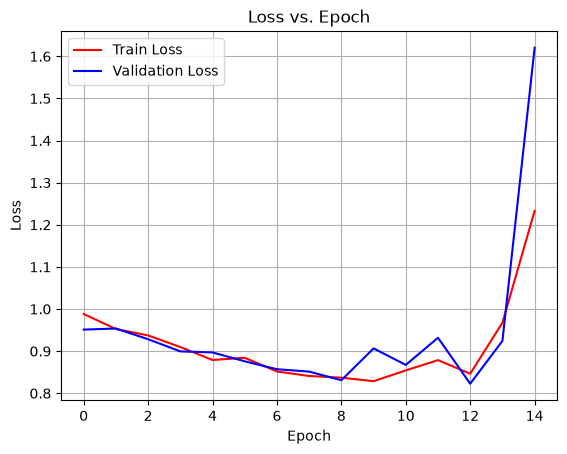

In [24]:
plt.plot(range(num_epochs), loss_train_hist, 'r', label="Train Loss")
plt.plot(range(num_epochs), loss_valid_hist, 'b', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs. Epoch")
plt.grid(True)
plt.legend()
plt.show()  

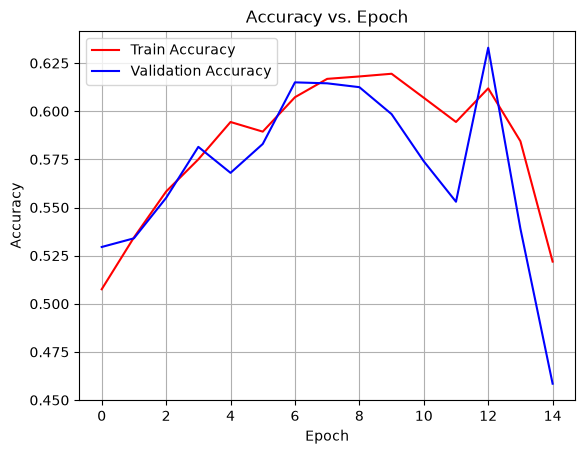

In [25]:
plt.plot(range(num_epochs), acc_train_hist, 'r', label="Train Accuracy")
plt.plot(range(num_epochs), acc_valid_hist, 'b', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Epoch")
plt.grid(True)
plt.legend()

In [ ]:
#Save the Best Model
checkpoint = {
    "model_state_dict": model.state_dict(),
    "vocab_size": VOCAB_SIZE,
    "embedding_dim": INPUT_SIZE,
    "hidden_dim": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "bidirectional": BIDIRECTIONAL,
    "num_classes": NUM_CLS,
    "max_seq_length": MAX_SEQ_LENGTH,
    "learning_rate": lr,
    "weight_decay": wd,
    "best_epoch": best_epoch,
    "best_validation_loss": best_loss_val
}

model_path = "rnn_tweet_eval_best.pth"
torch.save(checkpoint, model_path)

print("Best model saved successfully.")
print(f"Model path: {model_path}")
print(f"Best Epoch: {best_epoch}")
print(f"Best Validation Loss: {best_loss_val:.4f}")

In [ ]:
# Reload the Best Model
checkpoint = torch.load(model_path, map_location=device)

reloaded_model = RNNModel(
    RNN=nn.RNN,
    vocab_size=checkpoint["vocab_size"],
    input_size=checkpoint["embedding_dim"],
    hidden_size=checkpoint["hidden_dim"],
    num_layers=checkpoint["num_layers"],
    bidirectional=checkpoint["bidirectional"],
    num_cls=checkpoint["num_classes"]
).to(device)

reloaded_model.load_state_dict(checkpoint["model_state_dict"])
reloaded_model.eval()

print("Best model reloaded successfully.")
print(f"Reloaded Best Epoch: {checkpoint['best_epoch']}")
print(f"Reloaded Validation Loss: {checkpoint['best_validation_loss']:.4f}")

In [ ]:
# Test Evaluation
def evaluate_test(model, test_loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            inputs = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            targets = batch["label"].to(device)
            
            outputs = model(inputs, attention_mask)
            loss = loss_fn(outputs, targets)
            
            predictions = torch.argmax(outputs, dim=1)
            batch_size = inputs.size(0)
            
            total_loss += loss.item() * batch_size
            total_correct += (predictions == targets).sum().item()
            total_samples += batch_size
            
            all_predictions.extend(predictions.cpu().tolist())
            all_labels.extend(targets.cpu().tolist())
            
    test_loss = total_loss / total_samples
    test_accuracy = total_correct / total_samples
    
    return test_loss, test_accuracy, all_predictions, all_labels

test_loss, test_accuracy, predictions, true_labels = evaluate_test(
    reloaded_model,
    test_loader,
    loss_fn
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
# Save Test Predictions
import csv

sentiment_names = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

test_texts = dataset["test"]["text"]
prediction_path = "test_predictions.csv"

with open(prediction_path, "w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(["text", "true_label", "predicted_label", "predicted_sentiment"])
    
    for text, true_label, prediction in zip(test_texts, true_labels, predictions):
        writer.writerow([
            text,
            true_label,
            prediction,
            sentiment_names[prediction]
        ])

print("Test predictions saved successfully.")
print(f"Prediction file: {prediction_path}")
print(f"Number of predictions: {len(predictions)}")

In [ ]:
# Inspect Saved Test Predictions
import pandas as pd

pred_df = pd.read_csv("test_predictions.csv")

print("Shape:", pred_df.shape)
print("\nColumns:")
print(pred_df.columns.tolist())

print("\nFirst 5 predictions:")
display(pred_df.head())

print("\nTrue label distribution:")
print(pred_df["true_label"].value_counts())

print("\nPredicted label distribution:")
print(pred_df["predicted_label"].value_counts())

print("\nPredicted sentiment distribution:")
print(pred_df["predicted_sentiment"].value_counts())

Analysis of Learning Curves
​Based on the learning curves, here are the answers to the evaluation questions:  
​Did the training loss decrease during training?
Yes, training loss went down steadily from 0.9882 in Epoch 1 to around 0.83 in the middle epochs.  
​Did the validation loss decrease?
Yes, validation loss dropped from 0.9512 initially to a minimum of about 0.82–0.83 around Epochs 7 to 9.  
​Did the training accuracy improve?
Yes, training accuracy improved from 50.76% to around 61.9%.  
​Did the validation accuracy improve?
Yes, validation accuracy rose from 52.95% and peaked at around 61.5%–63.3%.  
​Is there evidence of overfitting?
Yes, there is clear evidence of overfitting toward the end.  
​If overfitting occurred, approximately when did it begin?
It started around Epoch 10. After that, validation loss spiked up to 1.62 and accuracy dropped, showing that Epoch 8 was the best stopping point.